# **Lab 08: Data Handling for Optimization and Quadratic Program**

**By N. Hemachandra**

### **Objective:** In **Lab08** we will perform optimization using a Pyomo from given data set and perform optimization of quadratic programs.

Use the following link to download dataset \\
[Click here to download](https://drive.google.com/drive/folders/1NSab5ErZHhXp8Tgg-Nn1c8quo3tugXFG?usp=sharing)


# **Creating Pyhton DataFrame**




### DataFrame can be created using Pandas library, first step will be to import pandas library, which can be done using the following command

```python
import pandas as pd

```




In [ ]:
import pandas as pd

## **Option 1**:

```python
# initialize data of lists.
data = {'Name': ['AA', 'AB', 'AD', 'AC'],
        'Age': [20, 21, 19, 18]}

# Create DataFrame
df = pd.DataFrame(data)

print(df)
```

In [ ]:
# initialize data of lists.
data = {'Name': ['AA', 'AB', 'AD', 'AC'],
        'Age': [20, 21, 19, 18]}

# Create DataFrame
df = pd.DataFrame(data)

print(df)

  Name  Age
0   AA   20
1   AB   21
2   AD   19
3   AC   18


## **Option 2**:
```python
name=["AA","AB","AC","AD"]
age=[20,21,19,18]
height=[165,175,168,180]

dict={"name":name,"age":age,"height":height}
df=pd.DataFrame(dict)

print(df)
```

In [ ]:
name=["AA","AB","AC","AD"]
age=[20,21,19,18]
height=[165,175,168,180]

dict={"name":name,"age":age,"height":height}
df=pd.DataFrame(dict)

print(df)

One can save dataframe to csv file using ".to_csv(file_name)"

```python
df.to_csv('file.csv')
```

In [ ]:
df.to_csv('file.csv')

## **Syntax for loop and conditional statements**

1. for loop, unlike matlab, indexing in python starts from 0.

```python
# loop from 0 to 4
for i in range(5):
  print(i)

# loop running over element of a list
list1=[1,2,3,4,5]
for i in list1:
  print(i)
```

2. if-elif statement

```python
a=5;

if a>5:
  print("a is greater than 5")
elif a==5:
  print("a is equal to 5")
else:
  print("a is less than 5")
```


In [ ]:
# loop from 0 to 4
for i in range(5):
  print(i)

# loop running over element of a list
list1=[1,2,3,4,5]
for i in list1:
  print(i)

0
1
2
3
4
1
2
3
4
5


# **Generalized Linear Program**

Given below is an standard basic optimization problem (minimization sense).

$$\begin{equation}
\min_{x} c^T x\\
\text{subject to} \\
\hspace{5em} Ax \leq b \\
\hspace{5em} l \leq x \leq u \\
\end{equation}
$$

where,


*   $c : \text{vector of cost coefficeint for variable $x$ of size $N \times 1$}$
*   $l : \text{vector of lower bound for variable $x$ of size $N \times 1$}$
*  $u : \text{vector of upper bound for variable $x$ of size $N \times 1$}$
*  $A : \text{matrix of cofficients for system constraints of size $M \times N$}$
*  $b : \text{vector of bound for contraints $x$ of size $M \times 1$}$

so that, for any $i^{th}$ row of $Ax \leq b$
$$ a_{i1} x_1 + a_{i2} x_2 + a_{i3} x_3 + ..... a_{iN} x_N \leq b_i $$


**Note:** $\big[ A: b\big]$ represents a matrix known as A augmented b of dimension $M \times N+1$ where vector $b$ is appended as another column in matrix $A$.

Given to you the data set `.csv` file about variable and [A:b] matrix. Solve the given optimization formulation using a ready-to-made python script in this sheet. \\


**Note**: *Carefully read all the instructions and ask TA(s) in case of any doubt(s)*.   

 ### **Step 1**: Install and import pyomo and also install GLPK solver as well

``` python
# Install and import pyomo
!pip install -q pyomo
from pyomo.environ import *

# Install solver as well into collab session
!apt-get install -y -qq glpk-utils
```

In [15]:
# Install and import pyomo
!pip install -q pyomo
from pyomo.environ import *

# Install solver as well into collab session
!apt-get install -y -qq glpk-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.1 MB/s eta 0:00:00
Selecting previously unselected package libsuitesparseconfig5:amd64.
(Reading database ... 123621 files and directories currently installed.)
Preparing to unpack .../libsuitesparseconfig5_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libamd2:amd64.
Preparing to unpack .../libamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libcolamd2:amd64.
Preparing to unpack .../libcolamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libcolamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libglpk40:amd64.
Preparing to unpack .../libglpk40_5.0-1_amd64.deb ...
Unpacking libglpk40:amd64 (5.0-1) ...
Selecting previously unselected package

### **Step 2**: Create an empty model framework using concerete model

``` python
# below variable defines an empty pyomo framework for optimization model
model = ConcreteModel()
```

In [ ]:
# below variable defines an empty pyomo framework for optimization model
model = ConcreteModel()

### **Step 3**: Before creating model import data using `pandas` by importing pandas library and loading dataset into Google Collab Session

```python
# You need to libraries pandas and numpy to import dataset and convert data into numpy array
import pandas as pd
import numpy as np
```


In [ ]:
# You need to libraries pandas and numpy to import dataset and convert data into numpy array
import pandas as pd
import numpy as np

```python
# we use two dataset for optimization problem as var_info representing all information about lower, upper bound and cost associated with decision variables
var_info = pd.read_csv("Variable.csv")
A_aug_b = pd.read_csv("A_augmented_b.csv")
```

In [ ]:
# we use two dataset for optimization problem as var_info representing all information about lower, upper bound and cost associated with decision variables
var_info = pd.read_csv("/content/Variable.csv")
A_aug_b = pd.read_csv("/content/A_augmented_b.csv")
print(var_info)
print(A_aug_b)

  variable    cost    lb    ub
0       x1  -9.600  -inf   4.0
1       x2  -2.850  -inf   inf
2       x3  41.500   0.0   inf
3       x4  33.050   0.0   2.0
4       x5  -0.750 -67.0  20.0
5       x6  20.500   0.0  55.0
6       x7  -0.350 -23.0  23.0
7       x8 -31.020  -5.0  15.0
8       x9  50.650   6.0   inf
9      x10   6.125   1.0   inf
  Unnamed: 0    x1    x2  x3    x4   x5   x6  x7  x8  x9   x10      b
0         c1  0.00  1.00  -2  0.00  1.0 -2.0   0   1   1 -1.00  35.40
1         c2 -1.00  1.00  -3  2.50  0.0  1.4   0  -2   1 -1.50  47.90
2         c3 -0.45  4.78  -2 -3.22 -1.3  1.0  -1   0   0  0.25  41.43
3         c4  1.00  0.00   0  0.00  1.0  1.0   0   2   3  0.00  22.70


### **Step 4**: In order to define model, first we need to define decision variables in system along with repective bounds on support
```python
# Let's us identify number of decision variable used in problem
no_var = len(var_info['variable'])

# Defining decision variable for pyomo framework
model.x = Var(np.arange(no_var))
```
**Note:** Here Var(np.arange(no_var)) used to define a vector of decision variables $x$ which has $(- \infty, \infty)$ as support by default of size `no_var`.

In [ ]:
# Let's us identify number of decision variable used in problem
no_var = len(var_info['variable'])

# Defining decision variable for pyomo framework
model.x = Var(np.arange(no_var))



```python
# Once decision variables are defined, our task is bound decision variables based on given data set in var_info`
for i in range(no_var):
  # since dataset is in text form, so we check for lower bound about -infinity and assign -infinity using np.inf otherwise given lower bound
  if var_info['lb'][i] == '-inf':
    model.x[i].setlb(-np.inf)
  else:
    model.x[i].setlb(var_info['lb'][i])

  # similarly we check for +infinity and assign infinity using numpy
  if var_info['ub'][i] == 'inf':
    model.x[i].setlb(np.inf)
  else:
    model.x[i].setub(var_info['ub'][i])
```

In [ ]:
# Once decision variables are defined, our task is bound decision variables based on given data set in var_info`
for i in range(no_var):
  # since dataset is in text form, so we check for lower bound about -infinity and assign -infinity using np.inf otherwise given lower bound
  if var_info['lb'][i] == '-inf':
    model.x[i].setlb(-np.inf)
  else:
    model.x[i].setlb(var_info['lb'][i])

  # similarly we check for +infinity and assign infinity using numpy
  if var_info['ub'][i] == 'inf':
    model.x[i].setub(np.inf)
  else:
    model.x[i].setub(var_info['ub'][i])

### **Step 5**: Next we need to define the constraints from the `[A:b]` matrix stored as `A_aug_b` dataset

```python
# multiple constraints can be defined using ConstraintList() which will store multiple constraints as a list
model.constraints = ConstraintList()

# defining number of constraints with help from given dataset
no_constr = A_aug_b.shape[0]

# segregating bounds on capacity from given dataset as b
b = np.array(A_aug_b['b'])

# A_ij is cofficient for the decision variables x_j against constraint i
A_ij = np.array(A_aug_b.iloc[:, 1:no_var+1])

# using for loop to store contraints in model
for i in range(no_constr):
  model.constraints.add(sum(A_ij[i][j]*model.x[j] for j in range(no_var)) <= b[i])

```

In [ ]:
# multiple constraints can be defined using ConstraintList() which will store multiple constraints as a list
model.constraints = ConstraintList()

# defining number of constraints with help from given dataset
no_constr = A_aug_b.shape[0]

# segregating bounds on capacity from given dataset as b
b = np.array(A_aug_b['b'])

# A_ij is cofficient for the decision variables x_j against constraint i
A_ij = np.array(A_aug_b.iloc[:, 1:no_var+1])

# using for loop to store contraints in model
for i in range(no_constr):
  model.constraints.add(sum(A_ij[i][j]*model.x[j] for j in range(no_var)) <= b[i])

### **Step 6**: Define your objective function as given optimization model

```python
# obj_coeff is cost cofficient for decision variables of objective fuction
obj_coeff = np.array(var_info['cost'])
# defining objective function for given problem and this completely defines optimization problem in Pyomo framework
model.objective = Objective(expr = summation(obj_coeff, model.x), sense=minimize)
```

In [ ]:
# obj_coeff is cost cofficient for decision variables of objective fuction
obj_coeff = np.array(var_info['cost'])
# defining objective function for given problem and this completely defines optimization problem in Pyomo framework
model.objective = Objective(expr = summation(obj_coeff, model.x), sense=minimize)

### **Step 7**: Check your model using `pprint()` and get it validated from your formulation

``` python
# this will provide summarize above defined model
model.pprint()
```

In [ ]:
# this will provide summarize above defined model
model.pprint()

1 Var Declarations
    x : Size=10, Index={0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
        Key : Lower : Value           : Upper : Fixed : Stale : Domain
          0 :  None :             4.0 :   4.0 : False : False :  Reals
          1 :  None : 5.8347280334728 :  None : False : False :  Reals
          2 :   0.0 :             0.0 :  None : False : False :  Reals
          3 :   0.0 :             0.0 :   2.0 : False : False :  Reals
          4 : -67.0 :           -29.3 :  20.0 : False : False :  Reals
          5 :   0.0 :             0.0 :  55.0 : False : False :  Reals
          6 : -23.0 :            23.0 :  23.0 : False : False :  Reals
          7 :  -5.0 :            15.0 :  15.0 : False : False :  Reals
          8 :   6.0 :             6.0 :  None : False : False :  Reals
          9 :   1.0 :             1.0 :  None : False : False :  Reals

1 Objective Declarations
    objective : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : mi

### **Step 8**: Solve your model and report your solution with objective value. Also, identify activity of various contraints. Explain your reasoning about activity.

In [ ]:
!apt-get install -y -qq glpk-utils
SolverFactory('glpk', executable='/usr/bin/glpsol').solve(model).write()
SolverFactory()

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: -196.378974895398
  Upper bound: -196.378974895398
  Number of objectives: 1
  Number of constraints: 4
  Number of variables: 10
  Number of nonzeros: 28
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 0.004599809646606445
# ----------------------------------------------------------
#   Solution Information
# ----------

In [ ]:
print("output= ", model.objective())

output=  -196.3789748953975


In [ ]:
print('\nDecision Variables')
for i in range(no_var):
  print(f'x[{i}] = ', model.x[i]())



Decision Variables
x[0] =  4.0
x[1] =  5.8347280334728
x[2] =  0.0
x[3] =  0.0
x[4] =  -29.3
x[5] =  0.0
x[6] =  23.0
x[7] =  15.0
x[8] =  6.0
x[9] =  1.0


**REPORT**



1.   The objective function value obtained is -196.38. This represents the minimized value of the objective function, achieved at the optimal solution.
2.   The optimal values for the decision variables are given in the output



# **Quadratic Program**

Formulation of the type

$$\begin{align*}
    \min_{x}: & \frac{1}{2}x^TPx + q^T x +s \\
    \textit{subject to}: \\
    & Gx \leq h \\
    & Ax = b \\
   l \leq & x \leq u\\
\end{align*}
$$

is known as a ***quadratic program*** with linear constraints due to quadratic nature of objective function. This particular class of problem are known as non-linear problem but are convex in nature. So, any local minima will be an eventual global minima for problem. \\

$x = \big[ x_1, x_2, \cdots x_n \big]$ is vector of decision variables. Further, $P$ is a positive (semi) definite matrix interpreted as coefficient of quadratic cost, $q$ is a vector of linear cost. $G$ is a matrix of coefficient of constraints and $h$ is vector of constraint capacity bounds. Similarly, $A$ and $b$ are matrix and vector representation of system affline constrants. Here, $l$ and $u$ are bounds on decision variable $x$.

Use the `qpsolvers` library to solve quadratic programs and any further help [Click Here](https://pypi.org/project/qpsolvers/) \\

Consider following problem:

$$\begin{align*}
    \min_{x} f(x): & \frac{1}{2} x_1^2 + x_2^2 - x_1 x_2 - 2x_1 - 6x_2\\
    \textit{subject to}: \\
     x_1 + x_2 & \leq 2 \\
     -x_1 + 2x_2 & \leq 2 \\
     2x_1 + x_2 & \leq 3 \\
     x_1 + x_2 & = \frac{1}{2} \\
     x_1, x_2 & \geq 0\\
    x_1, x_2 & \leq 1\\
\end{align*}
$$


Rewrite above equation in matrix notation and use below ready to made code in order to solve above optimization problem. You need to identify, $P$, $q$, $s$, $G$, $h$, $A$ $b$, $l$, $u$ from above given system.

Below is detailed description about how to use a quadratic optimization solver. We will be using `qpsolvers` for its simplicity in optimizing quadratic programs.

```python
# installing qpsolvers from web
!pip -q install qpsolvers[open_source_solvers]
from qpsolvers import solve_qp
import numpy as np
```

In [ ]:
# installing qpsolvers from web
!pip -q install qpsolvers[open_source_solvers]
from qpsolvers import solve_qp
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.7/526.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.8/979.8 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.2/508.2 kB 27.6 MB/s eta 0:00:00


Once you install your and import all necessary libraries, you need identify $P$, $q$, $s$, $G$, $h$, $A$ $b$, $l$, and $u$  to represent above mathematical formulation into matrix notations.

```python
# P represents quadratic cost coefficients
P = np.array([[]])
# q represents linear cost coefficients
q = np.array([]) # it will be an array
```

In [ ]:
# P represents quadratic cost coefficients
P = np.array([[0.5,-0.5],[-0.5,1]])
# q represents linear cost coefficients
q = np.array([[-2],[-6]]) # it will be an array
A = np.array([[1,1]])
b = np.array([1/2])

```python
# G matrix representation of coefficients of inequality constraints
G = np.array([[]])
# h vector representation of capacity bounds for inequality constraints
h = np.array([]) # it will be an array
```

In [ ]:
#G matrix representation of coefficients of inequality constraints
G = np.array([[1,1],[-1,2],[2,1]])
# h vector representation of capacity bounds for inequality constraints
h = np.array([2,2,3]) # it will be an array

Try solving your optimization problem as of now with only objective function and inequaility constraints with following snip to code

``` python
solve_qp(P, q, G, h, A, b, l, u, solver = "osqp")
```

By default it `solve_qp` uses 8 argument along with solver type. For now to solve initially use following:

``` python
solve_qp(P, q, G, h, None, None, None, None, solver = "osqp")
```


In [ ]:
solve_qp(P, q, G, h, None, None, None, None, solver = "osqp")

array([0.66628034, 1.33324427])

Add the equaility constaint to solve above formulation as

```python
# an array of an array to represent matrix to represent coefficient of constraints with equaility type.
A = np.array([[]])
# a vector to represent RHS of equality constraints
b = np.array([])

# now solve above formulation as
solve_qp(P, q, G, h, A, b, None, None, solver = "osqp")
```


In [ ]:
# an array of an array to represent matrix to represent coefficient of constraints with equaility type.
A = np.array([[1,1]])
# a vector to represent RHS of equality constraints
b = np.array([1/2])

# now solve above formulation as
solve_qp(P, q, G, h, A, b, None, None, solver = "osqp")

array([-0.33326882,  0.83321509])

At last you can define bounds on decision variables and solve quadratic program for optimality using following snip

```python
l = np.array([])
u = np.array([])

# solve for optimality as
x = solve_qp(P, q, G, h, A, b, l, u, solver = "osqp")

```

In [ ]:
l = np.array([0,0])
u = np.array([1,1])

# solve for optimality as
x_opt =  solve_qp(P, q, G, h, A, b, l, u, solver = "osqp")
objective_value = 0.5*x_opt.T@P@x_opt + q.T@x_opt
print(objective_value)

[-2.87488233]


/usr/local/lib/python3.10/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:24: UserWarning: Converted P to scipy.sparse.csc.csc_matrix
For best performance, build P as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:24: UserWarning: Converted G to scipy.sparse.csc.csc_matrix
For best performance, build G as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:24: UserWarning: Converted A to scipy.sparse.csc.csc_matrix
For best performance, build A as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(


**REPORT**

The code gives the results of solving a quadratic program (QP) using the OSQP
solver through the qpsolvers library in Python

The final optimal solution, x_opt, represents the values of the decision variables that minimize the objective function while satisfying all the defined constraints, where x_opt = -2.87

# QUESTION - 1(1)

In [ ]:
from pyomo.environ import*

In [ ]:
import pandas as pd

In [ ]:
obj = [1, 1, 1, 1, 1]
coef = [[85, 92, 45, 27, 31], [92, 54, 22, 20, 7], [96, 67, 29, 20, 11], [-91, -57, -33, -23, -12], [-99, -75, -26, -24, -41],[-98, -99, -57, -45, -65]]


In [ ]:
# Create a DataFrame for coefficients
coef_df = pd.DataFrame(coef, columns=['x1', 'x2', 'x3', 'x4', 'x5'])
coef_df

In [ ]:
coef_df["rhs"] = [1,1,1,1,1,1]
obj.append(0)
coef_df

In [ ]:
coef_df.loc[-1] = obj
coef_df.index = coef_df.index + 1
coef_df = coef_df.sort_index()
coef_df

In [ ]:
# Create a Pyomo model
model = ConcreteModel()

In [ ]:
# Define decision variables
model.u = Var(range(1, 6), within=NonNegativeReals)
model.x = Var(range(1, 6), within=Reals)

# Define objective function
model.obj = Objective(expr=sum(model.u[i] for i in range(1, 6)), sense=minimize)

In [ ]:
model.constraints = ConstraintList()
for id, row in coef_df.iterrows():
    model.constraints.add(sum(model.x[i] *row[f'x{i}'] for i in range(1, 6)) >= row['rhs'])

for i in range(1, 6):
    model.constraints.add(expr=model.u[i] >= model.x[i])
    model.constraints.add(expr=model.u[i] >= -model.x[i])

In [22]:
# Solve the model
solver = SolverFactory('glpk')
results = solver.solve(model)

In [23]:
# Display results
print("\nOptimization Results:")
print(f"Objective value: {model.obj()}")
for i in range(1, 6):
    print(f"u{i}: {model.u[i].value}, x{i}: {model.x[i].value}")


Optimization Results:
Objective value: 1.2047711958517482
u1: 0.123337005525986, x1: -0.123337005525986
u2: 0.237847475699376, x2: 0.237847475699376
u3: 0.284258681638594, x3: -0.284258681638594
u4: 0.364538122226498, x4: 0.364538122226498
u5: 0.194789910761294, x5: -0.194789910761294



REPORT
---



The minimum value of the objective function is: 1.2047711958517482

The optimization model was successfully constructed and solved using the GLPK solver. The results provide optimal values for the decision variables that minimize the defined objective function while satisfying all constraints.

# QUESTION - 1(2)

In [ ]:
import pandas as pd
from pyomo.environ import *

In [ ]:
obj = [1, 1, 1, 1, 1,None]
coef = [[85, 92, 45, 27, 31], [92, 54, 22, 20, 7], [96, 67, 29, 20, 11], [-91, -57, -33, -23, -12], [-99, -75, -26, -24, -41],[-98, -99, -57, -45, -65]]


In [ ]:
# Create a DataFrame for coefficients
coef_df = pd.DataFrame(coef, columns=['a1', 'a2', 'a3', 'a4', 'a5'])
coef_df["rhs"] = [1,1,1,1,1,1]
obj.append(0)
coef_df

In [ ]:
coef_df.loc[-1] = obj
coef_df.index = coef_df.index + 1
coef_df = coef_df.sort_index()
coef_df

In [ ]:
model = ConcreteModel()

In [ ]:
model.a = Var(range(1, 6), within=NonNegativeReals)
model.b = Var(range(1, 6), within=NonNegativeReals)
model.x = Var(range(1, 6), within=Reals)

model.obj = Objective(expr=sum(model.a[i] + model.b[i] for i in range(1, 6)), sense=minimize)

In [ ]:
model.constraints = ConstraintList()
for id, row in coef_df.iterrows():
    model.constraints.add(expr=sum(model.a[j] * row[j] for j in range(1, 6)) >= row['rhs'])

for i in range(1, 6):
    model.constraints.add(expr=model.a[i] - model.b[i] == model.x[i])

solver = SolverFactory('glpk')
results = solver.solve(model)

print("\nOptimization Results:")
print(f"Objective value: {model.obj()}")
for i in range(1, 6):
    print(f"a{i}: {model.a[i].value}, b{i}: {model.b[i].value}, x{i}: {model.x[i].value}")

REPORT

The minimum value of the objective function is: 1

#QUESTION - 2(1)

In [51]:
import pandas as pd
from pyomo.environ import *
import matplotlib.pyplot as plt

In [73]:
df = pd.read_csv("/content/Lab08_InterestRate.csv")

In [74]:
R_t = df['Ratio'].values
R = df['Rating'].values
r = df['Interest Rate'].values
n = len(r)

In [56]:
model = ConcreteModel()

In [57]:
model.b0 = Var(within=NonNegativeReals)
model.b1 = Var(within=Reals)
model.b2 = Var(within=Reals)

In [58]:
def objective_function(model):
    return sum((r[i] - (model.b0 + model.b1 * R_t[i] + model.b2 * R[i]))**2 for i in range(n))

In [59]:
model.obj = Objective(rule=objective_function, sense=minimize)

In [134]:
!pip install -q qpsolvers
from qpsolvers import solve_qp
import numpy as np

In [135]:
q = np.zeros((3, 3))
c = np.zeros(3)
A = np.zeros((0, 3))
b = np.zeros(0)

for i in range(n):
  q[0, 0] += 1
  q[0, 1] += R_t[i]
  q[0, 2] += R[i]
  q[1, 1] += R_t[i]**2
  q[1, 2] += R_t[i] * R[i]
  q[2, 2] += R[i]**2

  c[0] += -r[i]
  c[1] += -r[i] * R_t[i]
  c[2] += -r[i] * R[i]

q = q + q.T - np.diag(np.diag(q))

In [136]:
lb=np.array([0, -np.inf, -np.inf])
x = solve_qp(q, c, A, b, lb=lb, solver='osqp')
print(f"Optimal b0: {x[0]}, b1: {x[1]}, b2: {x[2]}")

Optimal b0: 0.09183646704536293, b1: 0.016672334506450146, b2: -0.0006990182240861285


/usr/local/lib/python3.10/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:24: UserWarning: Converted G to scipy.sparse.csc.csc_matrix
For best performance, build G as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(


[0.03802755598767205, 0.03229829058266666, 0.03457231596573038, 0.03508407517436794, 0.0374765555931379, 0.046977306923825575, 0.04731364025549566, 0.051198254090784844, 0.0438180612049911, 0.044222832985942415, 0.03664521601385843, 0.030461527771937807, 0.0319219837528948, 0.03150058015924509, 0.03434866271830698, 0.04591645851914144, 0.05042429182213012, 0.05334182879533477, 0.04480664959760751, 0.04541779237888336]


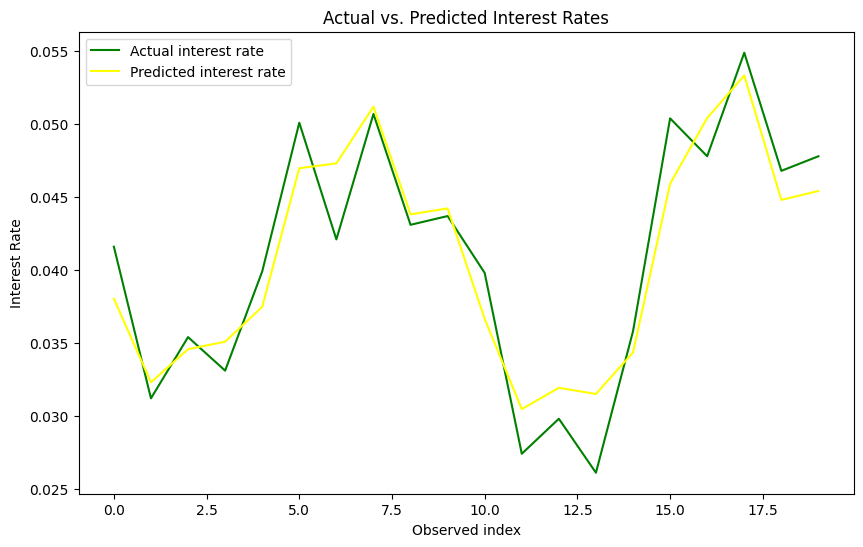

In [84]:
pdt_r = [x[0] + x[1] * R_t[i] + x[2] * R[i] for i in range(n)]
print(pdt_r)
plt.figure(figsize=(10, 6))
plt.plot(range(n),r, color='green', label='Actual interest rate')
plt.plot(range(n), pdt_r, color='yellow', label='Predicted interest rate')
plt.title('Actual vs. Predicted Interest Rates')
plt.xlabel('Observed index')
plt.ylabel('Interest Rate')
plt.legend()
plt.show()

REPORT

1.  The quadratic programming formulation was set up, with q representing the quadratic coefficients and c representing the linear coefficients.
2.  The optimization problem was solved using the OSQP solver from the qpsolvers library.
3.  b0: 0.09183646704536293 ; b1: 0.016672334506450146; b2: -0.0006990182240861285

# QUESTION - 2(2)

In [ ]:
!pip install -q qpsolvers

In [ ]:
import pandas as pd
from pyomo.environ import *
import numpy as np
from qpsolvers import solve_qp

In [ ]:
model = ConcreteModel()

In [ ]:
# Load the dataset
data = pd.read_csv('/content/Lab08_InterestRate.csv')

In [ ]:
# Extract columns
R_t = data['Ratio'].values
R = data['Rating'].values
r = data['Interest Rate'].values
n = len(r)

In [ ]:
# Create a model
model = ConcreteModel()

In [ ]:
# Define decision variables
model.b0 = Var(within=NonNegativeReals)
model.b1 = Var(within=Reals)
model.b2 = Var(within=Reals)
model.d = Var(range(n), within=NonNegativeReals)

In [ ]:
# Define the objective function
def obj_fn(model):
    return sum(model.d[i] for i in range(n))

model.obj = Objective(rule=objective_function, sense=minimize)

# Define constraints for absolute deviations
def absolute_deviation_constraints(model, i):
    return model.d[i] >= r[i] - (model.b0 + model.b1 * R_t[i] + model.b2 * R[i])
model.abs_dev_constraints = Constraint(range(n), rule=absolute_deviation_constraints)

def absolute_deviation_constraints_neg(model, i):
    return model.d[i] >= -(r[i] - (model.b0 + model.b1 * R_t[i] + model.b2 * R[i]))
model.abs_dev_constraints_neg = Constraint(range(n), rule=absolute_deviation_constraints_neg)


In [ ]:
# Solve the model
solver = SolverFactory('glpk')  # You can use a suitable solver
results = solver.solve(model)

# Display results
print(f"Optimal b0 = {model.b0()}\n b1 =  {model.b1()}\n b2 = {model.b2()}")

# Predict interest rates using the optimal parameters
pdt_r = [model.b0() + model.b1() * R_t[i] + model.b2() * R[i] for i in range(n)]
pdt_r

[0.03802755598767205, 0.03229829058266666, 0.03457231596573038, 0.03508407517436794, 0.0374765555931379, 0.046977306923825575, 0.04731364025549566, 0.051198254090784844, 0.0438180612049911, 0.044222832985942415, 0.03664521601385843, 0.030461527771937807, 0.0319219837528948, 0.03150058015924509, 0.03434866271830698, 0.04591645851914144, 0.05042429182213012, 0.05334182879533477, 0.04480664959760751, 0.04541779237888336]


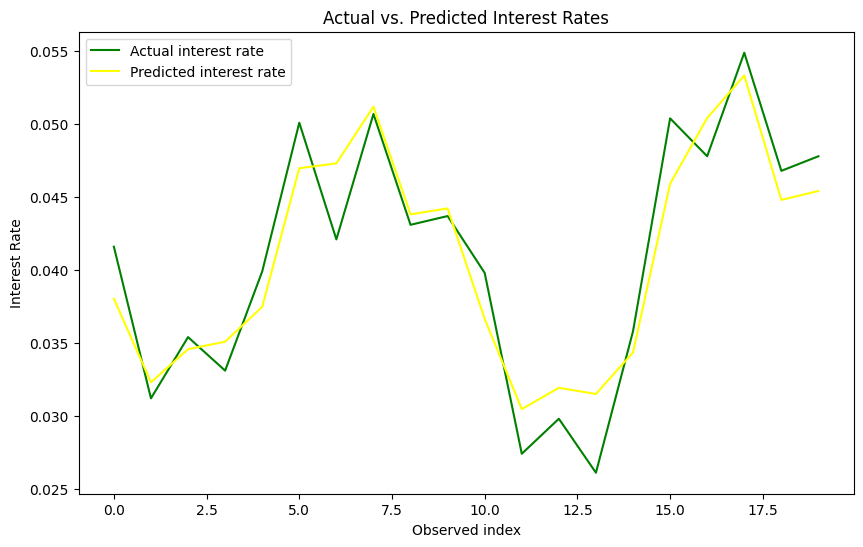

In [165]:
pdt_r = [x[0] + x[1] * R_t[i] + x[2] * R[i] for i in range(n)]
print(pdt_r)
plt.figure(figsize=(10, 6))
plt.plot(range(n),r, color='green', label='Actual interest rate')
plt.plot(range(n), pdt_r, color='yellow', label='Predicted interest rate')
plt.title('Actual vs. Predicted Interest Rates')
plt.xlabel('Observed index')
plt.ylabel('Interest Rate')
plt.legend()
plt.show()

REPORT

The optimization process yielded the following coefficients:


1.  b0 = 0.11547155119982
2.   b1 =  0.00931027338206423
3.  b2 = -0.000930122822534471
